In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
from numpy.polynomial import polynomial as P
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
df = pd.read_csv("/Users/cyriaque/timeseries-arma-sarima-forecast/serie", sep= " ", header=None, names=["t", "Xt"])

In [5]:
df.head(10)

,t,Xt
0,1,4.260665
1,2,3.519952
2,3,3.116867
3,4,3.893221
4,5,2.669689
5,6,2.479656
6,7,-0.435299
7,8,-0.554291
8,9,-3.152913
9,10,-1.998976


In [11]:
Zt= df["Xt"].diff(12).dropna().reset_index(drop=True)
Zt.index = range(1,len(Zt)+1)


In [12]:
Zt


1      0.580026
2     -0.240619
3     -0.607174
4     -2.002656
5     -2.642001
         ...   
984    1.329692
985    0.113409
986   -1.659076
987   -2.403389
988    1.325493
Name: Xt, Length: 988, dtype: float64

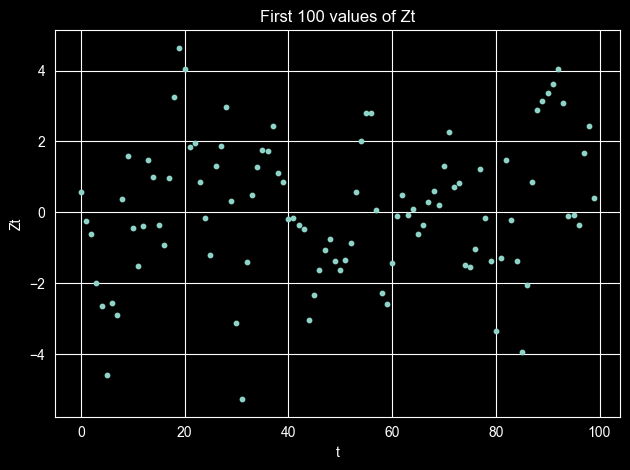

In [26]:
plt.scatter(range(100), Zt.iloc[:100], s=10)
plt.title("First 100 values of Zt")
plt.xlabel("t")
plt.ylabel("Zt")
plt.tight_layout()
plt.show()

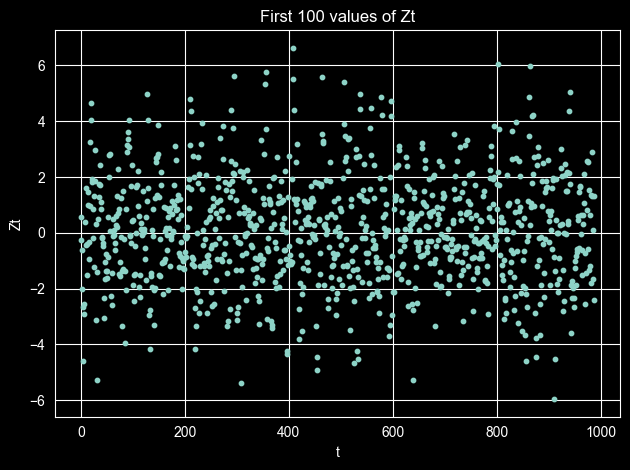

In [27]:
plt.scatter(range(len(Zt)), Zt, s=10)
plt.title("First 100 values of Zt")
plt.xlabel("t")
plt.ylabel("Zt")
plt.tight_layout()
plt.show()

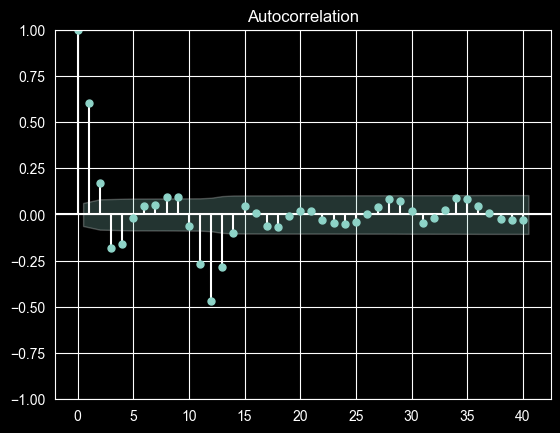

In [13]:
plot_acf(Zt, lags=40)
plt.show()

The ACF drops quickly and stay within the bands, so we can assume that the series is stationary.


We can check stationarity mathematically with the Dickey and Fuller method.

H0: The series has a unit root --> non-stationary

H1: The series is stationary

In [37]:
result = adfuller(Zt)
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF statistic: -9.9355
p-value: 0.0000000000000000275046824747660481122932


Here the p-value is less than 0.05 so we can reject H0. Hence the series is likely stationary, this is consistent with what we have observed on the ACF plot.


To determine the orders of the SARIMA model, we proceeded as follows.
First, we applied a seasonal differencing of order $d=12$ to obtain
$Z_t = (I - B^{12})X_t$. The ACF of $Z_t$ decays quickly and the Dickey and Fuller
test rejects the unit root hypothesis, confirming that $Z_t$ is
stationary. Hence $d=0$ and $D=1$.

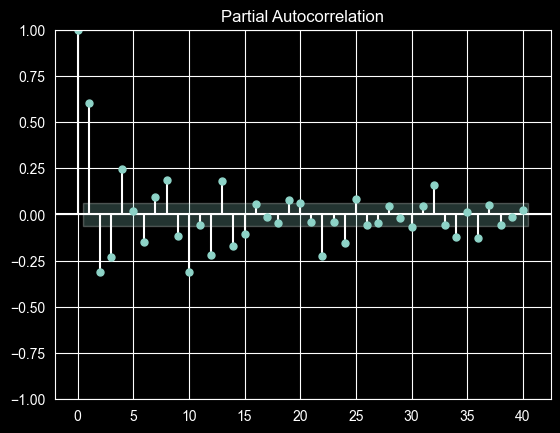

In [34]:
plot_pacf(Zt, lags=40)
plt.show()

At non-seasonal lags, the ACF of Zt shows significant spikes at lags 1 and 2 before cutting off, while
the PACF decays progressively, suggesting a MA(2) structure ($p=0, q=2$),
though an ARMA(1,1) cannot be excluded. At seasonal lags, both the ACF and
PACF exhibit a single significant spike at lag 12 with no spike at lag 24,
pointing to $P=1, Q=1$. The candidate model is therefore
SARIMA$(0,0,2)(1,1,1)_{12}$


We can run an AIC/BIC grid search to get confirmation.


In [50]:
warnings.filterwarnings("ignore")

best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None
results = []

for p, q, P, Q in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        model = SARIMAX(df["Xt"],
                        order=(p, 0, q),
                        seasonal_order=(P, 1, Q, 12)).fit(disp=False)
        results.append({"p": p, "q": q, "P": P, "Q": Q,
                        "AIC": round(model.aic, 2),
                        "BIC": round(model.bic, 2)})
        if model.aic < best_aic:
            best_aic = model.aic
            best_order_aic = (p, q, P, Q)
        if model.bic < best_bic:
            best_bic = model.bic
            best_order_bic = (p, q, P, Q)
    except Exception:
        continue

print(f"Best order (AIC): SARIMA{best_order_aic}, AIC={best_aic:.2f}")
print(f"Best order (BIC): SARIMA{best_order_bic}, BIC={best_bic:.2f}")

Best order (AIC): SARIMA(2, 2, 0, 1), AIC=2916.00
Best order (BIC): SARIMA(2, 2, 0, 1), BIC=2945.38


In [51]:
AIC_BIC_df = pd.DataFrame(results).sort_values("BIC")
AIC_BIC_df[:10]

,p,q,P,Q,AIC,BIC
33,2,2,0,1,2916.00,2945.38
35,2,2,1,1,2917.16,2951.43
21,1,2,0,1,2958.64,2983.12
23,1,2,1,1,2960.62,2989.99
9,0,2,0,1,2980.95,3000.53
11,0,2,1,1,2982.93,3007.41
29,2,1,0,1,3061.44,3085.92
25,2,0,0,1,3068.47,3088.05
31,2,1,1,1,3062.22,3091.60
27,2,0,1,1,3069.56,3094.04


In [52]:
warnings.filterwarnings("ignore")

best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None
results = []

for p, q, P, Q in itertools.product(range(5), range(5), range(2), range(2)):
    try:
        model = SARIMAX(df["Xt"],
                        order=(p, 0, q),
                        seasonal_order=(P, 1, Q, 12)).fit(disp=False)
        results.append({"p": p, "q": q, "P": P, "Q": Q,
                        "AIC": round(model.aic, 2),
                        "BIC": round(model.bic, 2)})
        if model.aic < best_aic:
            best_aic = model.aic
            best_order_aic = (p, q, P, Q)
        if model.bic < best_bic:
            best_bic = model.bic
            best_order_bic = (p, q, P, Q)
    except Exception:
        continue

print(f"Best order (AIC): SARIMA{best_order_aic}, AIC={best_aic:.2f}")
print(f"Best order (BIC): SARIMA{best_order_bic}, BIC={best_bic:.2f}")

Best order (AIC): SARIMA(4, 4, 0, 1), AIC=2805.50
Best order (BIC): SARIMA(3, 3, 0, 1), BIC=2849.96


In [55]:
AIC_BIC_df = pd.DataFrame(results).sort_values("BIC")
AIC_BIC_df[:10]

,p,q,P,Q,AIC,BIC
73,3,3,0,1,2810.80,2849.96
97,4,4,0,1,2805.50,2854.46
99,4,4,1,1,2809.06,2862.92
93,4,3,0,1,2824.23,2868.29
75,3,3,1,1,2824.73,2868.79
77,3,4,0,1,2828.90,2872.96
95,4,3,1,1,2826.68,2875.63
79,3,4,1,1,2886.76,2935.71
49,2,2,0,1,2916.00,2945.38
69,3,2,0,1,2916.39,2950.66


The grid search returns SARIMA$(4,0,4)(0,1,1)_{12}$ as the best model
according to AIC, and SARIMA$(3,0,3)(0,1,1)_{12}$ according to BIC.
Both criteria agree on $P=0$ and $Q=1$, confirming that one seasonal MA
term is sufficient to capture the seasonality at lag 12. The disagreement
on the non-seasonal orders ($p,q$) is expected: AIC tends to favor more
complex models while BIC penalizes additional parameters more heavily,
hence selecting a more parsimonious specification. We retain the BIC
model SARIMA$(3,0,3)(0,1,1)_{12}$ as it is asymptotically consistent, whereas the AIC has a positive probability of selecting an overfitted model asymptotically.

In [56]:
final_model = SARIMAX(df["Xt"],
                      order = (3,0,3),
                      seasonal_order = (0, 1, 1, 12)).fit(disp=False)

forecast = final_model.forecast(steps=100)


In [64]:
forecast

1000     9.884227
1001     9.325406
1002     8.674983
1003     8.299289
1004     8.819543
          ...    
1095    12.342865
1096    10.865104
1097     9.655102
1098     9.174301
1099     9.183417
Name: predicted_mean, Length: 100, dtype: float64

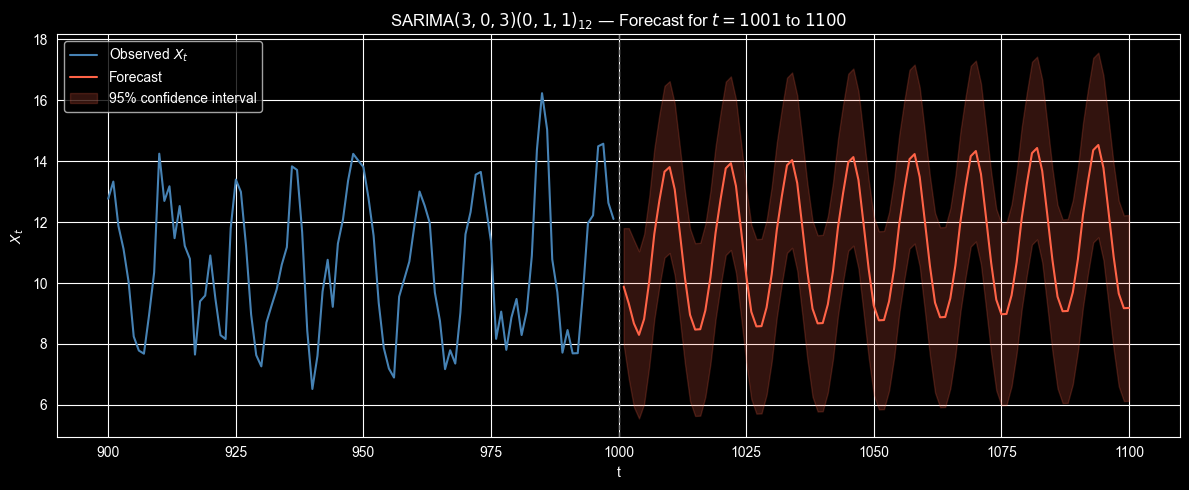

In [72]:
forecast_mean = forecast_obj.predicted_mean.values
conf_int = forecast_obj.conf_int().values

plt.figure(figsize=(12, 5))

plt.plot(range(900, 1000), df["Xt"].iloc[900:1000].values,
         color="steelblue", label="Observed $X_t$")

plt.plot(range(1001, 1101), forecast_mean,
         color="tomato", label="Forecast")

plt.fill_between(range(1001, 1101),
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color="tomato", alpha=0.2, label="95% confidence interval")

plt.axvline(x=1000, color="gray", linestyle="--", linewidth=1)
plt.title("SARIMA$(3,0,3)(0,1,1)_{12}$ — Forecast for $t=1001$ to $1100$")
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
df["Xt"][950:1000]

950    13.810756
951    12.789512
952    11.554212
953     9.351603
954     7.868377
955     7.191526
956     6.897246
957     9.553564
958    10.127609
959    10.705844
960    11.899109
961    13.006483
962    12.545144
963    11.976732
964     9.692072
965     8.756702
966     7.173013
967     7.793694
968     7.356621
969     9.025536
970    11.605748
971    12.333402
972    13.560007
973    13.650116
974    12.510918
975    11.363677
976     8.168578
977     9.062460
978     7.807895
979     8.867538
980     9.479144
981     8.293086
982     9.069571
983    10.895252
984    14.378061
985    16.235243
986    15.038738
987    10.779744
988     9.701793
989     7.715873
990     8.457138
991     7.691247
992     7.698773
993     9.641464
994    11.969459
995    12.224944
996    14.491470
997    14.576167
998    12.635349
999    12.105237
Name: Xt, dtype: float64

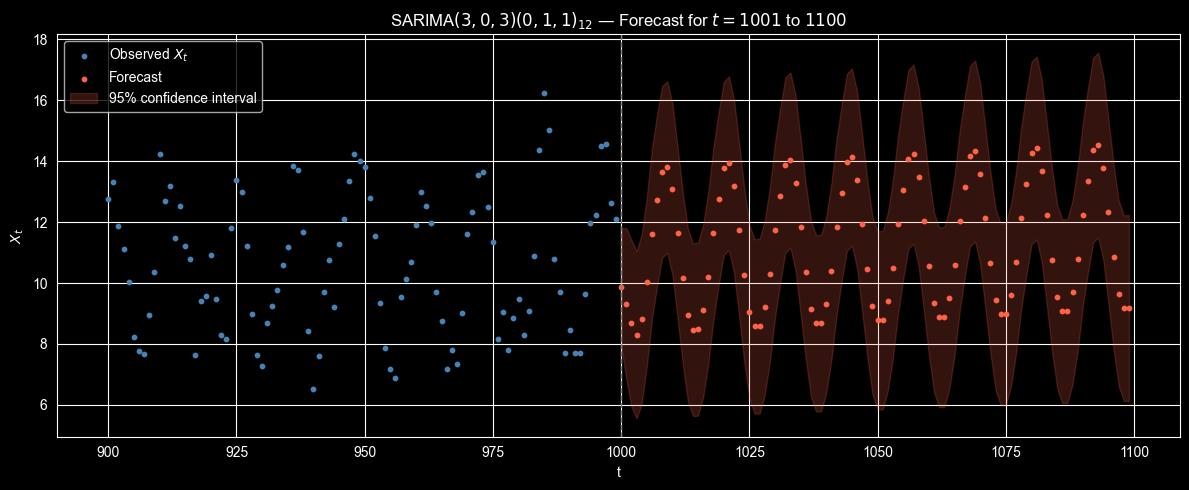

In [76]:
forecast_mean = forecast_obj.predicted_mean.values
conf_int = forecast_obj.conf_int().values

plt.figure(figsize=(12, 5))

plt.scatter(range(900, 1000), df["Xt"].iloc[900:1000].values,
            color="steelblue", label="Observed $X_t$", s=10)

plt.scatter(range(1000, 1100), forecast_mean,
            color="tomato", label="Forecast", s=10)

plt.fill_between(range(1000, 1100),
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color="tomato", alpha=0.2, label="95% confidence interval")

plt.axvline(x=1000, color="gray", linestyle="--", linewidth=1)
plt.title("SARIMA$(3,0,3)(0,1,1)_{12}$ — Forecast for $t=1001$ to $1100$")
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.legend()
plt.tight_layout()
plt.show()